In [1]:
import pandas as pd
import numpy as np

# Create a sample DataFrame
data = {'A': [0.5, 1.5, 2.0, 0.8],
        'B': [1.2, 0.7, 1.9, 2.5],
        'C': [2.2, 0.2, 0.5, 1.0]}

df = pd.DataFrame(data)

# Use NumPy to find values greater than 1
mask = np.where(df.values > 1)

result = pd.DataFrame({
    'Row': mask[0],
    'Column': mask[1],
    'Value': df.values[mask]
})

print(result)

   Row  Column  Value
0    0       1    1.2
1    0       2    2.2
2    1       0    1.5
3    2       0    2.0
4    2       1    1.9
5    3       1    2.5


In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch

from flonacomldft.models.mlp import MLP
from flonacomldft.train_mlp_from_data import train_mlp

from flonacomldft.utils.data_processing import load_datasets
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data

import matplotlib.pyplot as plt

## 1. Train MLPs with MD to compute energy of initial random samples

In [35]:
isomer_ids = [0, 1]
datasets = [load_datasets('andersen', id, real_centered=True) for id in isomer_ids]

In [36]:
datasets

[{'train': tensor([[ 1.5815e-01,  4.0123e-02, -9.2729e-02,  ...,  4.7450e-02,
           -6.6173e+00,  0.0000e+00],
          [-8.9056e-02,  5.9808e-02, -8.2768e-02,  ...,  9.8265e-03,
           -6.7860e+00,  0.0000e+00],
          [ 3.8803e-03, -2.2048e-02,  2.5274e-01,  ..., -2.4731e-01,
           -6.7482e+00,  0.0000e+00],
          ...,
          [-1.8079e-02,  2.8027e-02,  1.3297e-01,  ...,  8.1083e-01,
           -6.7381e+00,  0.0000e+00],
          [-1.7869e-01,  1.5525e-02,  4.1332e-03,  ...,  1.2572e-02,
           -6.6871e+00,  0.0000e+00],
          [ 1.8351e-01, -4.8571e-02,  1.3461e-01,  ..., -6.6597e-01,
           -6.6198e+00,  0.0000e+00]], grad_fn=<CatBackward0>),
  'test': tensor([[ 3.7879e-02, -6.8475e-02, -6.5937e-03,  ..., -1.9951e-01,
           -6.7265e+00,  0.0000e+00],
          [ 2.0617e-01, -1.0393e-01,  1.3095e-01,  ..., -7.0481e-02,
           -6.5622e+00,  0.0000e+00],
          [ 6.4927e-02,  1.1729e-01,  2.1595e-01,  ..., -9.5282e-02,
           -6.735

In [23]:
device = 'cpu'

In [4]:
mlp_args = {'hidden_depth': 8,
        'hidden_dim': 156,
        'n_iter': 2500,
        'learning_rate': 1e-3,
        'batch_size': 512,
        'use_scheduler': True,
        'step_scheduler': 200,
}

mlp_dicts = []

for id in isomer_ids:
    
    xs_train, xs_test = datasets[id]['train'], datasets[id]['test']

    model = MLP([12] + [ mlp_args['hidden_dim'] ] * mlp_args['hidden_depth'] + [1])


    mlp_dic = train_mlp(model, 
                xs_train, 
                xs_test, 
                n_iter=mlp_args['n_iter'],
                lr=mlp_args['learning_rate'],
                use_scheduler=mlp_args['use_scheduler'],
                step_schedule=mlp_args['step_scheduler'],
                with_tqdm=False)

    mlp_dicts.append(mlp_dic)

train shape:  torch.Size([4000, 12])
test shape:  torch.Size([1000, 12])
t=0.0e+00 	 loss train: 4.31e+01 	 loss test: 4.24e+01 	 lr: 1.00e-03


t=2.5e+02 	 loss train: 2.46e-04 	 loss test: 2.96e-04 	 lr: 5.00e-04
t=5.0e+02 	 loss train: 9.15e-05 	 loss test: 1.16e-04 	 lr: 2.50e-04
t=7.5e+02 	 loss train: 4.78e-05 	 loss test: 6.58e-05 	 lr: 1.25e-04
t=1.0e+03 	 loss train: 2.96e-05 	 loss test: 4.06e-05 	 lr: 3.13e-05
t=1.2e+03 	 loss train: 2.22e-05 	 loss test: 3.01e-05 	 lr: 1.56e-05
t=1.5e+03 	 loss train: 1.82e-05 	 loss test: 2.49e-05 	 lr: 7.81e-06
t=1.8e+03 	 loss train: 1.61e-05 	 loss test: 2.21e-05 	 lr: 3.91e-06
t=2.0e+03 	 loss train: 1.48e-05 	 loss test: 2.05e-05 	 lr: 9.77e-07
t=2.2e+03 	 loss train: 1.44e-05 	 loss test: 2.00e-05 	 lr: 4.88e-07
train shape:  torch.Size([4000, 12])
test shape:  torch.Size([1000, 12])
t=0.0e+00 	 loss train: 4.21e+01 	 loss test: 4.16e+01 	 lr: 1.00e-03
t=2.5e+02 	 loss train: 1.55e-04 	 loss test: 2.20e-04 	 lr: 5.00e-04
t=5.0e+02 	 loss train: 8.39e-05 	 loss test: 1.10e-04 	 lr: 2.50e-04
t=7.5e+02 	 loss train: 5.00e-05 	 loss test: 8.02e-05 	 lr: 1.25e-04
t=1.0e+03 	 loss 

In [5]:
xs_train, xs_test = [], []

for id in isomer_ids:
    xs_train.append(datasets[id]['train'])
    xs_test.append(datasets[id]['test'])

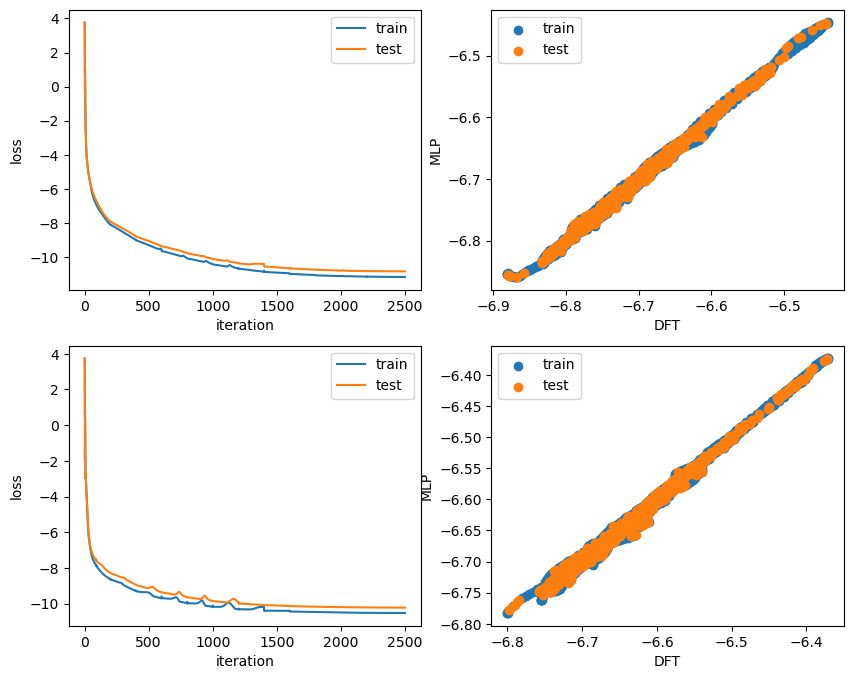

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for id in isomer_ids:

    axs[id][0].plot(torch.log(torch.tensor(mlp_dicts[id]['train_loss'])), label='train')
    axs[id][0].plot(torch.log(torch.tensor(mlp_dicts[id]['test_loss'])), label='test')
    axs[id][0].set_xlabel('iteration')
    axs[id][0].set_ylabel('loss')

    axs[id][0].legend()

    axs[id][1].scatter(xs_train[id][:, 12].detach().numpy().flatten(), mlp_dicts[id]['model'](xs_train[id][:, :12]).detach().numpy().flatten(), label='train')
    axs[id][1].scatter(xs_test[id][:, 12].detach().numpy().flatten(), mlp_dicts[id]['model'](xs_test[id][:, :12]).detach().numpy().flatten(), label='test')
    axs[id][1].set_xlabel('DFT')
    axs[id][1].set_ylabel('MLP')

    axs[id][1].legend()

In [7]:
xs_samples = [load_pickle_file('/home/amolina/assisting_sampling/adaptive-sampling/MLP/0-gaussian-samples/us_dft_samples_is{:d}.pkl'.format(id), '') for id in isomer_ids]

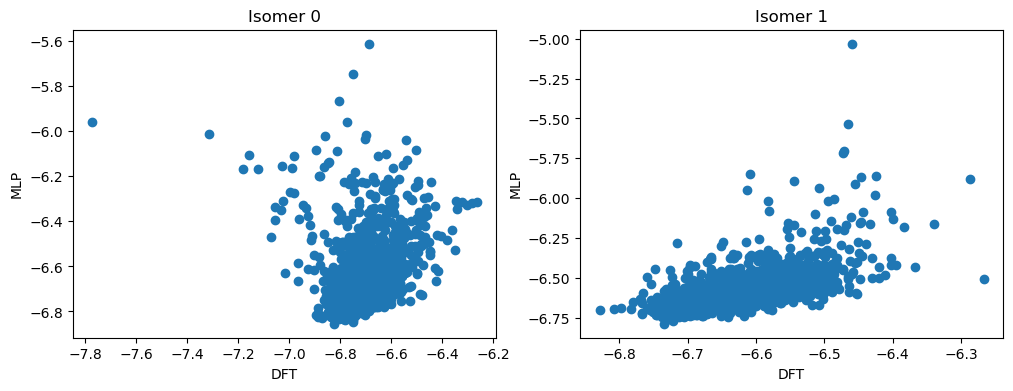

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for id, ax in zip(isomer_ids, axs):
    ax.scatter(mlp_dicts[id]['model'](xs_samples[id][0]).detach().numpy().flatten(),
                 xs_samples[id][1])
    ax.set_xlabel('DFT')
    ax.set_ylabel('MLP')

    ax.set_title('Isomer {:d}'.format(id))


## 2. Train MLPs with random samples to compute energy of MD

In [9]:
xs_gauss = [torch.cat((xs_samples[id][0], torch.tensor(xs_samples[id][1]).reshape(-1, 1)), dim=1)
            for id in isomer_ids]

In [21]:
mlp_args = {'hidden_depth': 8,
        'hidden_dim': 256,
        'n_iter': 10000,
        'learning_rate': 1e-4,
        'batch_size': 512,
        'use_scheduler': True,
        'step_scheduler': 2000,
}

mlp_dicts = []

for id in isomer_ids:
    
    xs_train, xs_test = xs_gauss[id], datasets[id]['test']

    model = MLP([12] + [ mlp_args['hidden_dim'] ] * mlp_args['hidden_depth'] + [1])


    mlp_dic = train_mlp(model, 
                xs_train, 
                xs_test, 
                n_iter=mlp_args['n_iter'],
                lr=mlp_args['learning_rate'],
                use_scheduler=mlp_args['use_scheduler'],
                step_schedule=mlp_args['step_scheduler'],
                with_tqdm=False)

    mlp_dicts.append(mlp_dic)

train shape:  torch.Size([1000, 12])
test shape:  torch.Size([1000, 12])
t=0.0e+00 	 loss train: 4.44e+01 	 loss test: 4.56e+01 	 lr: 1.00e-04


t=1.0e+03 	 loss train: 3.76e-03 	 loss test: 4.99e-03 	 lr: 2.50e-05
t=2.0e+03 	 loss train: 2.38e-03 	 loss test: 4.63e-03 	 lr: 6.25e-06
t=3.0e+03 	 loss train: 2.00e-03 	 loss test: 4.53e-03 	 lr: 1.56e-06
t=4.0e+03 	 loss train: 1.88e-03 	 loss test: 4.51e-03 	 lr: 3.91e-07
t=5.0e+03 	 loss train: 1.84e-03 	 loss test: 4.50e-03 	 lr: 9.77e-08
t=6.0e+03 	 loss train: 1.82e-03 	 loss test: 4.50e-03 	 lr: 2.44e-08
t=7.0e+03 	 loss train: 1.82e-03 	 loss test: 4.50e-03 	 lr: 6.10e-09
t=8.0e+03 	 loss train: 1.82e-03 	 loss test: 4.50e-03 	 lr: 1.53e-09
t=9.0e+03 	 loss train: 1.82e-03 	 loss test: 4.50e-03 	 lr: 3.81e-10
train shape:  torch.Size([1000, 12])
test shape:  torch.Size([1000, 12])
t=0.0e+00 	 loss train: 4.25e+01 	 loss test: 4.33e+01 	 lr: 1.00e-04
t=1.0e+03 	 loss train: 3.74e-03 	 loss test: 5.19e-03 	 lr: 2.50e-05
t=2.0e+03 	 loss train: 2.22e-03 	 loss test: 4.33e-03 	 lr: 6.25e-06
t=3.0e+03 	 loss train: 1.91e-03 	 loss test: 4.11e-03 	 lr: 1.56e-06
t=4.0e+03 	 loss 

In [24]:
xs_train, xs_test = [], []

for id in isomer_ids:
    xs_train.append(xs_gauss[id])
    xs_test.append(datasets[id]['test'])

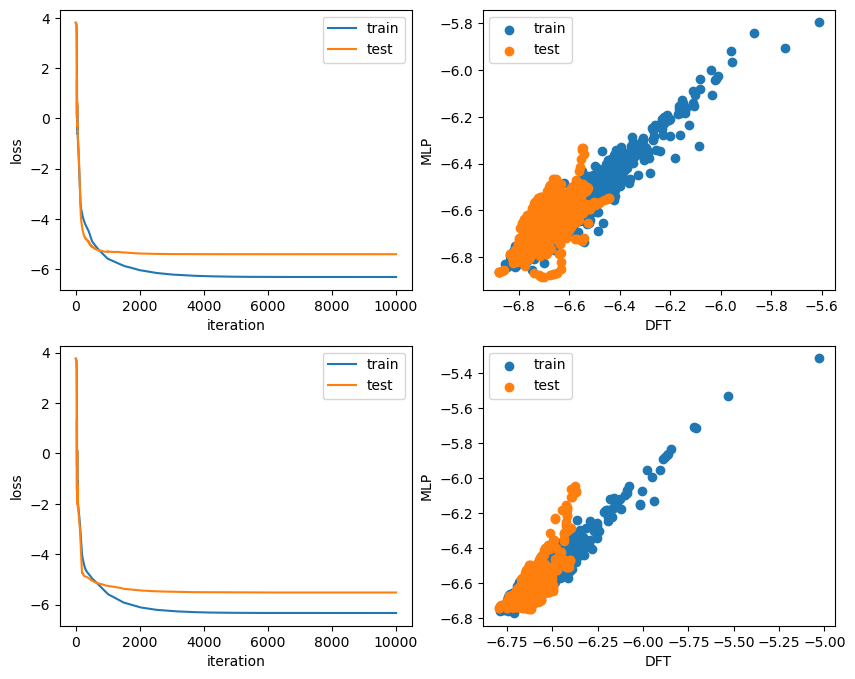

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for id in isomer_ids:

    axs[id][0].plot(torch.log(torch.tensor(mlp_dicts[id]['train_loss'])), label='train')
    axs[id][0].plot(torch.log(torch.tensor(mlp_dicts[id]['test_loss'])), label='test')
    axs[id][0].set_xlabel('iteration')
    axs[id][0].set_ylabel('loss')

    axs[id][0].legend()

    axs[id][1].scatter(xs_train[id][:, 12].detach().numpy().flatten(), mlp_dicts[id]['model'](xs_train[id][:, :12]).detach().numpy().flatten(), label='train')
    axs[id][1].scatter(xs_test[id][:, 12].detach().numpy().flatten(), mlp_dicts[id]['model'](xs_test[id][:, :12]).detach().numpy().flatten(), label='test')
    axs[id][1].set_xlabel('DFT')
    axs[id][1].set_ylabel('MLP')

    axs[id][1].legend()

## 3. Adaptive retraining MLP

In [109]:
adaptives_mcmc_mlp = [load_pickle_file(#'/home/amolina/assisting_sampling/adaptive-sampling/MLP/1-adaptive/results_adaptive_is1_20230918000706/adaptive_sampling_is1_20230918000706.pkl'
    '/home/amolina/assisting_sampling/adaptive-sampling/MLP/1-adaptive/results_adaptive_is1_20230918144454/adaptive_sampling_is1_20230918144454.pkl', '')]

In [110]:
len(adaptives_mcmc_mlp)

1

In [111]:
accs_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_mlp]

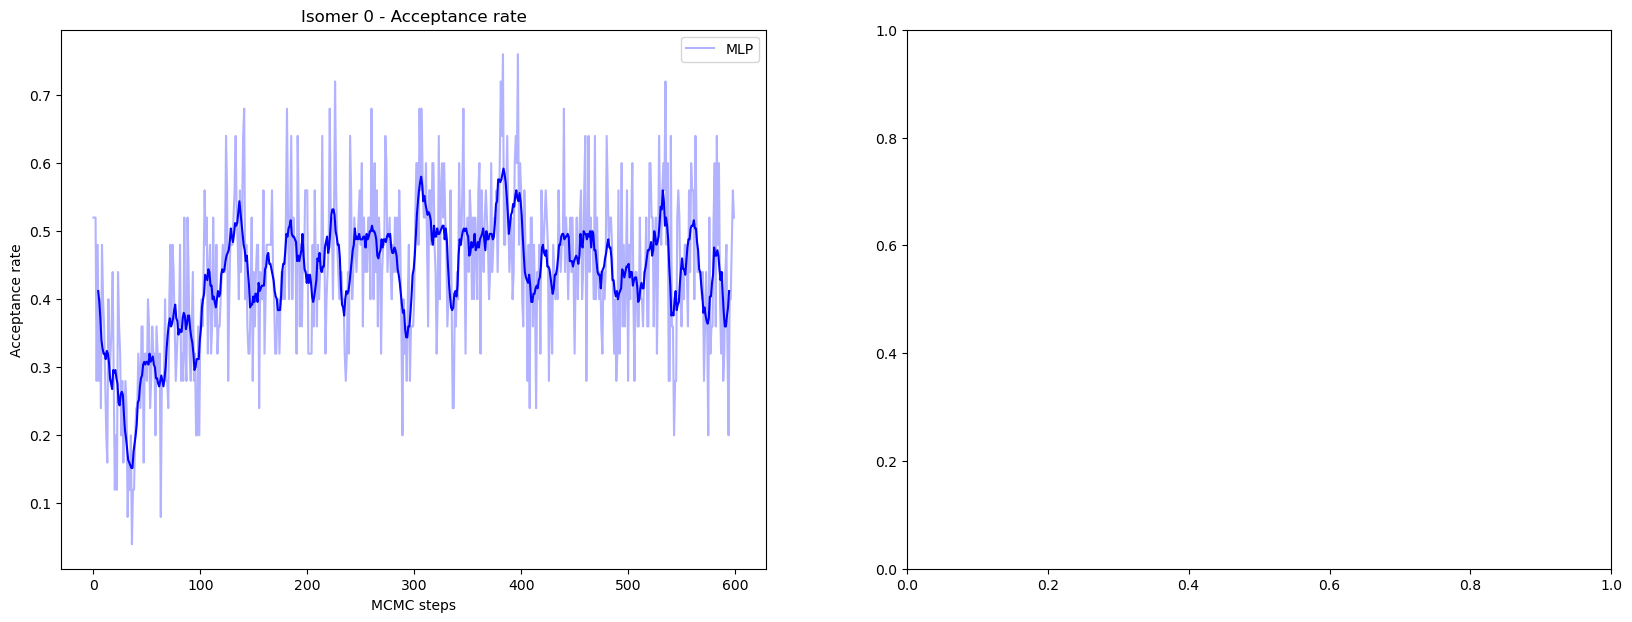

In [113]:
accs_mlp = [torch.cat(adaptive_mcmc['accs']).mean(dim=1) for adaptive_mcmc in adaptives_mcmc_mlp]

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(accs_mlp)):

    #set_plot_sequential_data(accs_dft[i], ax=axs[i], color='red', label='DFT')
    set_plot_sequential_data(accs_mlp[i], ax=axs[i], color='blue', label='MLP')

    axs[i].set_xlabel('MCMC steps')
    axs[i].set_ylabel('Acceptance rate')
    axs[i].set_title(f'Isomer {i} - Acceptance rate')

    axs[i].legend()

### 1.c Loss flow

In [114]:
losses_mlp = [torch.cat([adaptives_mcmc_mlp[i]['dict_flows_training'][j][0]['losses'][0]
                            for j in range(len(adaptives_mcmc_mlp[i]['dict_flows_training']))
                            ])
                            for i in range(len(accs_mlp))]

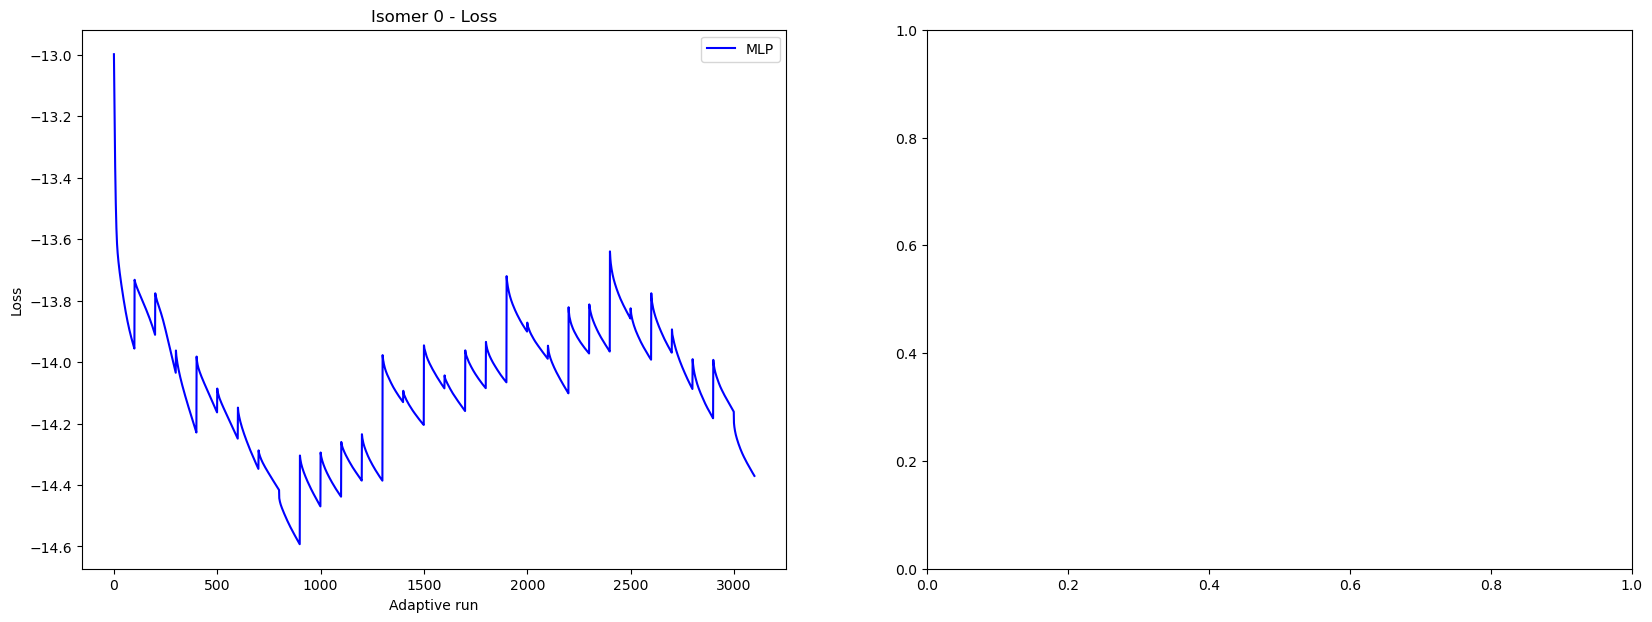

In [115]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for i in range(len(losses_mlp)):
    set_plot_sequential_data(losses_mlp[i], ax=axs[i], color='blue', label='MLP', alpha=1, avg=False)

    axs[i].set_xlabel('Adaptive run')
    axs[i].set_ylabel('Loss')
    axs[i].set_title(f'Isomer {i} - Loss')

    axs[i].legend()

### 1.d Loss mlp

In [116]:
adaptives_mcmc_mlp[0]['dict_mlps_training'][1][0]

{'model': MLP(
   (linears): ModuleList(
     (0): Linear(in_features=12, out_features=128, bias=True)
     (1): Linear(in_features=128, out_features=128, bias=True)
     (2): Linear(in_features=128, out_features=128, bias=True)
     (3): Linear(in_features=128, out_features=1, bias=True)
   )
 ),
 'train_loss': [3.368398756720126e-05,
  1.1889007510035299e-05,
  1.0766387276817113e-05,
  1.0175484021601733e-05,
  9.92638524621725e-06,
  9.163805771095213e-06,
  8.414791409450117e-06,
  8.817765774438158e-06,
  8.054380487010349e-06,
  7.5237162491248455e-06,
  6.909367129992461e-06,
  6.274221959756687e-06,
  5.896366019442212e-06,
  5.657051588059403e-06,
  5.84278859605547e-06,
  5.576472631219076e-06,
  5.111431164550595e-06,
  4.830715624848381e-06,
  4.923708729620557e-06,
  5.113686256663641e-06,
  5.143040198163362e-06,
  5.270218935038429e-06,
  4.935870038025314e-06,
  4.252151029504603e-06,
  4.131438799959142e-06,
  4.203941898595076e-06,
  4.663597337639658e-06,
  6.080605

In [117]:
losses_mlp_mlp = []

for j in range(1, len(adaptives_mcmc_mlp[0]['dict_mlps_training'])):
    losses_mlp_mlp.append(adaptives_mcmc_mlp[0]['dict_mlps_training'][j][0]['train_loss'])

In [118]:
losses_mlp_mlp = [ torch.stack( [torch.tensor(adaptives_mcmc_mlp[0]['dict_mlps_training'][j][0]['train_loss'])
                             for j in range(1, len(adaptives_mcmc_mlp[0]['dict_flows_training'])) ] ).flatten() ]

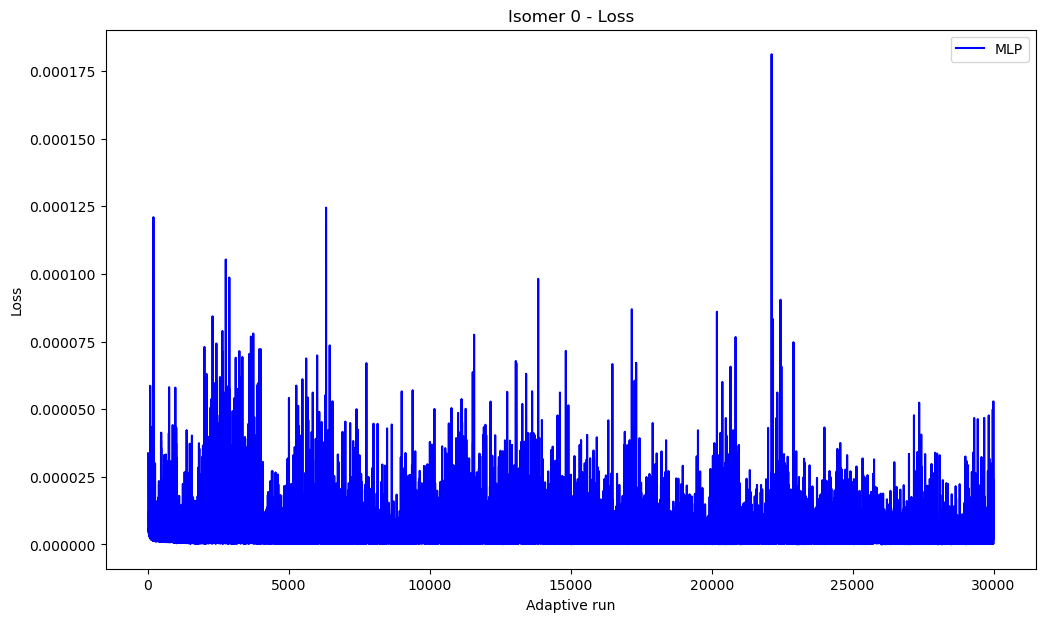

In [119]:
fig, axs = plt.subplots(1, 1, figsize=(12, 7))

for i in range(len(losses_mlp_mlp)):
    set_plot_sequential_data(losses_mlp_mlp[i], ax=axs, color='blue', label='MLP', alpha=1, avg=False)

    axs.set_xlabel('Adaptive run')
    axs.set_ylabel('Loss')
    axs.set_title(f'Isomer {i} - Loss')

    axs.legend()

## 2. $\hat{R}$ test 

In [100]:

from flonacomldft.utils.diagnostics import (
    R_hat,
)

In [101]:
xs_mlp = [torch.cat(adaptive_mcmc['xs']).detach().numpy().transpose(1, 0, 2) for adaptive_mcmc in adaptives_mcmc_mlp]

In [102]:
rhat_mlp = [R_hat(x) for x in xs_mlp]

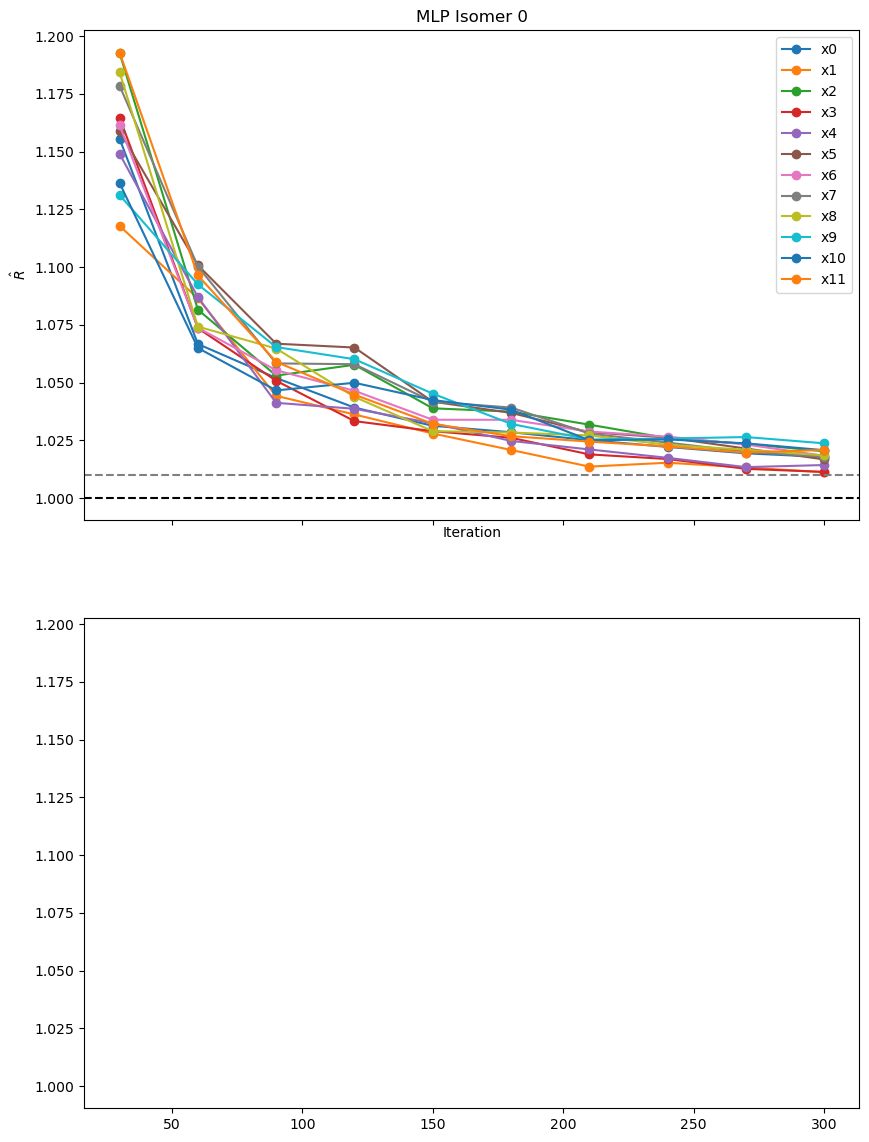

In [103]:
fig, axs = plt.subplots(2, 1, figsize=(10, 14), sharex=True, sharey=True)

for i in range(len(rhat_mlp)):
    #axs[i][0].plot(rhat_dft[i][1], rhat_dft[i][0], '-o',  label=rhat_dft[i][2])
    #axs[i][0].axhline(1, c='k', ls='--')
    #axs[i][0].axhline(1.01, c='grey', ls='--')
    #axs[i][0].set_xlabel('Iteration')
    #axs[i][0].set_ylabel(r'$\hat{R}$')
    #axs[i][0].legend()
    #axs[i][0].set_title('DFT Isomer {}'.format(i))

    axs[i].plot(rhat_mlp[i][1], rhat_mlp[i][0], '-o',  label=rhat_mlp[i][2])
    axs[i].axhline(1, c='k', ls='--')
    axs[i].axhline(1.01, c='grey', ls='--')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel(r'$\hat{R}$')
    axs[i].legend()
    axs[i].set_title('MLP Isomer {}'.format(i))